## Drone Rescue Environment Implementation

Implement the custom `DroneRescueEnv` class.

**Initial Configuration:**

Group ID that ends with **9**. This leads to the following environment parameters:

*   **Grid Size:** 6x6
*   **Rescue Targets:** 3
*   **Charging Stations:** 2
*   **Danger Zones:** 4
*   **Blocked Cells:** 3
*   **Maximum Battery:** 15 units (since 9 is an odd digit)
*   **Wind Probability:** 30% (0.3)

The starting position (S) is fixed at (0,0) as per the problem statement.

In [1]:
# Import necessary libraries
import numpy as np
import random
from collections import defaultdict

# --- Constants for Actions ---
UP = 0
DOWN = 1
LEFT = 2
RIGHT = 3
HOVER = 4

ACTIONS = [UP, DOWN, LEFT, RIGHT, HOVER]
ACTION_NAMES = {UP: "Up", DOWN: "Down", LEFT: "Left", RIGHT: "Right", HOVER: "Hover"}

# --- Constants for Cell Types ---
FREE = 'F'
DANGER = 'D'
RESCUE = 'R'
CHARGE = 'C'
WIND = 'W'
BLOCKED = 'X'
START = 'S'

# --- Reward Structure ---
REWARD_RESCUE = 20
REWARD_DANGER = -10
REWARD_BATTERY_EXHAUSTED = -20
REWARD_CHARGING_STATION = 5
REWARD_MOVEMENT = -1

# --- Environment Parameters (Group ID ending in 9) ---
GRID_SIZE = (6, 6)
MAX_BATTERY = 15
MAX_BATTERY_INCENTIVE= 15
WIND_PROB = 0.3
MAX_STEPS = 75 # For 6x6 grid


In [2]:
class DroneRescueEnv:
    def __init__(self, grid_size=GRID_SIZE, max_battery=MAX_BATTERY, wind_prob=WIND_PROB, max_steps=MAX_STEPS):
        self.grid_size = grid_size
        self.rows, self.cols = grid_size
        self.max_battery = max_battery
        self.wind_prob = wind_prob
        self.max_steps = max_steps
        self.current_step = 0

        self.start_pos = (0, 0) # Fixed at top-left corner, moved this line up
        # Initial grid configuration based on Group ID 
        self.initial_grid_config = self._generate_initial_grid_config()

        self.grid = None  # Will be set in reset()

        self.state = None  # (row, col, battery, rescued_targets_tuple)
        self.all_possible_states = [] # To be populated by generate_all_states

        self.reset()

    def _generate_initial_grid_config(self):
        
        # For a 6x6 grid: 3 rescue, 2 charging, 4 danger, 3 blocked
        # This method is for demonstration. In a real scenario, this would be randomized 
        # grid_cells = [
        #     [START,  FREE,    FREE,   DANGER,  FREE,    RESCUE],
        #     [FREE,   WIND,    FREE,   FREE,    BLOCKED, FREE],
        #     [FREE,   CHARGE,  FREE,   DANGER,  FREE,    FREE],
        #     [DANGER, FREE,    FREE,   FREE,    CHARGE,  RESCUE],
        #     [FREE,   BLOCKED, FREE,   WIND,    FREE,    FREE],
        #     [RESCUE, FREE,    DANGER, BLOCKED, FREE,    FREE]
        # ]
        grid_cells = [
            [START,  FREE,    FREE,    DANGER, FREE,    RESCUE],
            [FREE,   BLOCKED, WIND,    FREE,   FREE,    FREE],
            [FREE,   FREE,    FREE,    FREE,   CHARGE,  FREE],
            [DANGER, FREE,    BLOCKED, FREE,   FREE,    RESCUE],
            [FREE,   WIND,    FREE,    FREE,   CHARGE,  FREE],
            [RESCUE, FREE,    DANGER,  FREE,   BLOCKED, FREE]
        ]
        # Ensure no overlap with start position
        if grid_cells[self.start_pos[0]][self.start_pos[1]] != START:
            grid_cells[self.start_pos[0]][self.start_pos[1]] = START

        return np.array(grid_cells)

    def _get_state_tuple(self, pos, battery, rescued_targets):
        return (pos[0], pos[1], battery, tuple(rescued_targets))

    def reset(self):
        self.grid = np.copy(self.initial_grid_config)
        self.current_pos = self.start_pos
        self.battery = self.max_battery #Attention pls
        self.current_step = 0

        # Identify initial rescue targets and their status
        self.rescue_target_locations = []
        for r in range(self.rows):
            for c in range(self.cols):
                if self.grid[r, c] == RESCUE:
                    self.rescue_target_locations.append((r, c))
        self.rescued_targets = [False] * len(self.rescue_target_locations)

        self.state = self._get_state_tuple(self.current_pos, self.battery, self.rescued_targets)
        return self.state

    def _get_next_position(self, current_pos, action):
        r, c = current_pos
        dr, dc = 0, 0
        if action == UP: dr = -1
        elif action == DOWN: dr = 1
        elif action == LEFT: dc = -1
        elif action == RIGHT: dc = 1
        # HOVER means dr=0, dc=0

        new_r, new_c = r + dr, c + dc

        # Check boundaries
        if not (0 <= new_r < self.rows and 0 <= new_c < self.cols):
            return current_pos, False  # Stay in place if out of bounds

        # Check blocked cells
        if self.initial_grid_config[new_r, new_c] == BLOCKED: # Use initial_grid_config for blocked cells
            return current_pos, False  # Stay in place if blocked

        return (new_r, new_c), True

    def step(self, action):
        self.current_step += 1
        reward = REWARD_MOVEMENT # Default movement cost
        done = False
        info = {}

        original_pos = self.current_pos
        original_battery = self.battery
        original_rescued_targets = list(self.rescued_targets) # Copy for comparison

        # 1. Battery consumption for any action
        self.battery -= 1
        if self.battery <= 0:
            reward += REWARD_BATTERY_EXHAUSTED
            done = True
            info['reason'] = 'battery_exhausted'
            self.state = self._get_state_tuple(self.current_pos, 0, self.rescued_targets) # Set battery to 0 for terminal state
            return self.state, reward, done, info

        # Handle Hover action special case
        if action == HOVER:
            if self.grid[original_pos[0], original_pos[1]] == CHARGE:
                # If hovering on charging station, battery increases, no movement cost
                self.battery += 3 # Hover cost was -1, so effectively +2 #Attention pls
                self.battery = min(self.battery, self.max_battery) # Cap battery
               # reward += REWARD_CHARGING_STATION + 1 # Add charge reward and negate hover movement cost #Attention pls
            else:
                # Hovering elsewhere still consumes 1 battery unit (already handled above)
                pass
            # No change in position for hover
            next_pos = original_pos
        else:
            # Handle wind for movement actions if in a wind zone
            if self.grid[original_pos[0], original_pos[1]] == WIND and random.random() < self.wind_prob:
                # Wind disturbance: choose random direction (excluding hover)
                wind_action = random.choice([UP, DOWN, LEFT, RIGHT])
                next_pos, moved = self._get_next_position(original_pos, wind_action)
                info['wind_effect'] = f'Wind changed action from {ACTION_NAMES[action]} to {ACTION_NAMES[wind_action]}'
            else:
                next_pos, moved = self._get_next_position(original_pos, action)

            self.current_pos = next_pos

        # 2. Update state based on new position
        cell_type = self.grid[self.current_pos[0], self.current_pos[1]]

        # Handle Charging Station entry
        if cell_type == CHARGE and original_pos != self.current_pos: # Only on entry
            self.battery = MAX_BATTERY_INCENTIVE#self.max_battery
            reward += REWARD_CHARGING_STATION

        # Handle Rescue Target
        if cell_type == RESCUE:
            target_idx = -1
            for i, loc in enumerate(self.rescue_target_locations):
                if loc == self.current_pos and not self.rescued_targets[i]:
                    target_idx = i
                    break

            if target_idx != -1:
                self.rescued_targets[target_idx] = True
                reward += REWARD_RESCUE
                # Make the rescue target disappear (become a free cell)
                self.grid[self.current_pos[0], self.current_pos[1]] = FREE
                info['rescued'] = True

        # Handle Danger Zone
        if cell_type == DANGER:
            reward += REWARD_DANGER
            info['entered_danger'] = True

        # Check termination conditions
        if all(self.rescued_targets):
            done = True
            info['reason'] = 'all_rescued'
        elif self.current_step >= self.max_steps:
            done = True
            info['reason'] = 'max_steps_exceeded'

        self.state = self._get_state_tuple(self.current_pos, self.battery, self.rescued_targets)
        return self.state, reward, done, info

    def render(self):
        display_grid = np.copy(self.grid)
        r, c = self.current_pos
        display_grid[r, c] = 'DRONE'

        print(f"--- Step: {self.current_step}, Battery: {self.battery}/{self.max_battery} ---")
        for row_idx, row in enumerate(display_grid):
            row_str = " ".join(row)
            # Highlight rescue targets that are not yet rescued
            for i, target_loc in enumerate(self.rescue_target_locations):
                if not self.rescued_targets[i] and target_loc[0] == row_idx:
                    # Check if the target is in the current row before trying to highlight
                    if target_loc[1] < len(row):
                        col_char_start = target_loc[1] * 2 # Each cell is 'X ' or 'XX '
                        row_str = row_str[:col_char_start] + '\033[93m' + row_str[col_char_start] + '\033[0m' # Yellow
            print(row_str)

        rescued_status = " ".join(["R" if s else "_" for s in self.rescued_targets])
        print(f"Rescued Targets: [{rescued_status}]")
        print("------------------------------------")

    def get_all_possible_states(self):
        if not self.all_possible_states:
            # This can be computationally intensive for larger grids, but necessary for DP
            states = set()
            # Re-initialize rescue_target_locations from initial_grid_config to get consistent target count
            temp_rescue_target_locations = []
            for r in range(self.rows):
                for c in range(self.cols):
                    if self.initial_grid_config[r, c] == RESCUE:
                        temp_rescue_target_locations.append((r, c))
            num_targets = len(temp_rescue_target_locations)

            for r in range(self.rows):
                for c in range(self.cols):
                    if self.initial_grid_config[r, c] == BLOCKED:
                        continue # Drone cannot be in a blocked cell
                    for b in range(1, self.max_battery + 1): # Battery cannot be 0, it's a terminal state if reached
                        for i in range((2**num_targets)):
                            # Generate all combinations of rescued targets status
                            rescued_status = [(i >> j) & 1 == 1 for j in range(num_targets)]
                            states.add((r, c, b, tuple(rescued_status)))

            # Add terminal states (battery 0)
            for r in range(self.rows):
                for c in range(self.cols):
                    if self.initial_grid_config[r,c] == BLOCKED:
                        continue
                    for i in range(2**num_targets):
                        rescued_status = [(i >> j) & 1 == 1 for j in range(num_targets)]
                        states.add((r, c, 0, tuple(rescued_status))) # Battery 0 states are terminal

            # Add terminal states (all targets rescued)
            all_targets_rescued_tuple = tuple([True] * num_targets)
            for r in range(self.rows):
                for c in range(self.cols):
                    if self.initial_grid_config[r,c] == BLOCKED:
                        continue
                    for b in range(self.max_battery + 1): # Can be any battery level if all rescued
                        states.add((r, c, b, all_targets_rescued_tuple))

            # Ensure the start state is included if it's not a blocked cell
            if self.initial_grid_config[self.start_pos[0], self.start_pos[1]] != BLOCKED:
                 states.add(self._get_state_tuple(self.start_pos, self.max_battery, tuple([False] * num_targets)))

            self.all_possible_states = sorted(list(states))
        return self.all_possible_states

    def is_terminal_state(self, state):
        pos_r, pos_c, battery, rescued_targets_tuple = state

        # If battery is 0, it's a terminal state
        if battery <= 0:
            return True

        # If all targets are rescued, it's a terminal state
        if all(rescued_targets_tuple):
            return True

        return False

    def get_transition_model(self, state, action):
        # Returns a list of (probability, next_state, reward) tuples
        # state: (r, c, battery, rescued_targets_tuple)
        # action: UP, DOWN, LEFT, RIGHT, HOVER

        transitions = []

        # Unpack current state
        r, c, battery, rescued_targets_tuple = state
        current_pos = (r, c)
        current_rescued_targets = list(rescued_targets_tuple)

        # If it's already a terminal state, no further transitions are possible.
        if self.is_terminal_state(state):
            return [(1.0, state, 0)] # Stay in terminal state with 0 reward

        # --- Simulate battery consumption ---
        next_battery = battery - 1
        reward = REWARD_MOVEMENT # Default movement cost

        # Check for immediate battery exhaustion
        if next_battery <= 0:
            # The episode terminates here. Next state will have 0 battery.
            next_state_if_battery_exhausted = self._get_state_tuple(current_pos, 0, rescued_targets_tuple)
            return [(1.0, next_state_if_battery_exhausted, reward + REWARD_BATTERY_EXHAUSTED)]

        # --- Handle Hover action special case ---
        if action == HOVER:
            next_pos = current_pos
            if self.initial_grid_config[r, c] == CHARGE: # Use initial_grid_config for static features
                next_battery = min(battery + 3, self.max_battery) # Hover cost was -1, so effectively +2 #Attention pls # battery +2 because -1 was consumed
                #reward += REWARD_CHARGING_STATION + 1 # +1 to compensate for REWARD_MOVEMENT
            else:
                # Hovering elsewhere still consumes 1 battery (already handled by next_battery = battery - 1)
                pass

            # No change in rescued targets for hover
            next_rescued_targets = current_rescued_targets
            next_state = self._get_state_tuple(next_pos, next_battery, next_rescued_targets)
            transitions.append((1.0, next_state, reward))

        # --- Handle Movement actions (UP, DOWN, LEFT, RIGHT) ---
        else:
            # Determine if wind affects movement
            if self.initial_grid_config[r, c] == WIND: # Use initial_grid_config for static features
                # Wind disturbance: multiple possible next states
                # Probability of intended action vs. random action
                intended_prob = 1.0 - self.wind_prob
                random_prob_per_dir = self.wind_prob / 4.0 # Uniformly distributed among UP, DOWN, LEFT, RIGHT

                # Intended action
                next_pos_intended, moved_intended = self._get_next_position(current_pos, action)
                self._add_transition(transitions, next_pos_intended, next_battery, current_rescued_targets, reward, intended_prob, current_pos, state)

                # Random actions due to wind
                for wind_action in [UP, DOWN, LEFT, RIGHT]:
                    next_pos_wind, moved_wind = self._get_next_position(current_pos, wind_action)
                    self._add_transition(transitions, next_pos_wind, next_battery, current_rescued_targets, reward, random_prob_per_dir, current_pos, state)
            else:
                # No wind: deterministic movement
                next_pos, moved = self._get_next_position(current_pos, action)
                self._add_transition(transitions, next_pos, next_battery, current_rescued_targets, reward, 1.0, current_pos, state)

        # Consolidate transitions to the same state
        consolidated_transitions = defaultdict(lambda: {'prob': 0.0, 'reward': 0.0})
        for prob, n_state, rwd in transitions:
            consolidated_transitions[n_state]['prob'] += prob
            consolidated_transitions[n_state]['reward'] += prob * rwd # Weighted average reward for a state

        final_transitions = []
        for n_state, data in consolidated_transitions.items():
            final_transitions.append((data['prob'], n_state, data['reward'] / data['prob']))

        return final_transitions

    def _add_transition(self, transitions_list, next_pos, next_battery, current_rescued_targets, base_reward, prob, original_pos, current_state):
        # Helper to add a transition, applying cell-specific rewards and target updates
        temp_reward = base_reward
        temp_rescued_targets = list(current_rescued_targets)
        next_grid_config_at_pos = self.initial_grid_config[next_pos[0], next_pos[1]] # Use initial_grid_config for static features

        # Handle Charging Station entry
        if next_grid_config_at_pos == CHARGE and next_pos != original_pos:
            next_battery = self.max_battery # Battery becomes full
            temp_reward += REWARD_CHARGING_STATION

        # Handle Rescue Target
        if next_grid_config_at_pos == RESCUE:
            target_idx = -1
            for i, loc in enumerate(self.rescue_target_locations):
                if loc == next_pos and not temp_rescued_targets[i]:
                    target_idx = i
                    break

            if target_idx != -1:
                temp_rescued_targets[target_idx] = True
                temp_reward += REWARD_RESCUE
                # Note: In the MDP, we consider the immediate reward and state transition.
                # The actual grid cell changing from R to F is a side effect that modifies the environment
                # for future `step` calls, but for DP, the 'rescued_targets_tuple' in the state defines this.

        # Handle Danger Zone
        if next_grid_config_at_pos == DANGER:
            temp_reward += REWARD_DANGER

        next_state = self._get_state_tuple(next_pos, next_battery, temp_rescued_targets)
        transitions_list.append((prob, next_state, temp_reward))



### Environment Test (Optional)

Here's a small demonstration of the environment to check its basic functionality. You can run this cell to see how the drone moves and interacts with the grid.

## Dynamic Programming: Value Iteration

 Value Iteration algorithm to find the optimal value function $V^*(s)$ and optimal policy $\pi^*(s)$ for the `DroneRescueEnv`.

**Key parameters for Value Iteration:**
*   **Discount Factor (gamma, $\gamma$):** 0.95 (a common choice for MDPs)
*   **Stopping Threshold (theta, $\theta$):** $10^{-3}$ (as specified in the problem statement)

This implementation will iterate through all possible states, calculate the expected value of each action, and update the state's value function until the change in values falls below the specified threshold.

In [3]:
import time

# --- Value Iteration Parameters ---
GAMMA = 0.99  # Discount factor
THETA = 1e-3  # Stopping threshold

def value_iteration(env, gamma=GAMMA, theta=THETA):
    print(f"Starting Value Iteration with gamma={gamma}, theta={theta}")
    start_time = time.time()

    # Get all possible states from the environment
    all_states = env.get_all_possible_states()
    num_states = len(all_states)

    # Map state tuples to integer indices for easier lookup
    state_to_idx = {state: i for i, state in enumerate(all_states)}
    idx_to_state = {i: state for i, state in enumerate(all_states)}

    # Initialize value function V(s) to zeros for all states
    V = np.zeros(num_states)

    # Initialize policy to an empty dictionary
    policy = {}

    # Store number of iterations for analysis
    iterations = 0
    max_delta = float('inf')

    while max_delta > theta:
        max_delta = 0
        iterations += 1
        new_V = np.copy(V)

        for i, s in enumerate(all_states):
            if env.is_terminal_state(s):
                new_V[i] = 0 # Value of terminal states is 0
                continue

            # Calculate V(s) for each action
            q_values = np.zeros(len(ACTIONS)) # Q(s,a)

            for a in ACTIONS:
                # Get transitions for the current state and action
                # returns list of (prob, next_state, reward) tuples
                transitions = env.get_transition_model(s, a)

                expected_value = 0
                for prob, next_s, r in transitions:
                    next_s_idx = state_to_idx.get(next_s, -1) # Get index, -1 if state not found
                    if next_s_idx == -1:
                        # This should not happen if get_all_possible_states is comprehensive
                        print(f"Warning: next_s {next_s} not found in all_states for state {s}, action {a}")
                        # If it's truly an unreachable/invalid state, treat its value as 0 or a very negative number
                        expected_value += prob * (r + gamma * 0)
                    else:
                        expected_value += prob * (r + gamma * V[next_s_idx])
                q_values[a] = expected_value

            # Update V(s) to the maximum Q(s,a) over all actions
            best_q_value = np.max(q_values)
            max_delta = max(max_delta, abs(new_V[i] - best_q_value))
            new_V[i] = best_q_value

        V = new_V # Update V for the next iteration

        if iterations % 10 == 0:
            print(f"Iteration {iterations}: Max Delta = {max_delta:.6f}")

    # --- Policy Extraction (after V has converged) ---
    for i, s in enumerate(all_states):
        if env.is_terminal_state(s):
            policy[s] = -1 # No action in terminal state
            continue

        q_values = np.zeros(len(ACTIONS))
        for a in ACTIONS:
            transitions = env.get_transition_model(s, a)
            expected_value = 0
            for prob, next_s, r in transitions:
                next_s_idx = state_to_idx.get(next_s, -1)
                if next_s_idx == -1: # Defensive check
                    expected_value += prob * (r + gamma * 0)
                else:
                    expected_value += prob * (r + gamma * V[next_s_idx])
            q_values[a] = expected_value

        # Choose action with the maximum Q-value (ties can be broken arbitrarily)
        best_action = np.argmax(q_values)
        policy[s] = best_action

    end_time = time.time()
    runtime = end_time - start_time

    print(f"Value Iteration converged in {iterations} iterations with final delta {max_delta:.6f} in {runtime:.2f} seconds.")

    return V, policy, state_to_idx, idx_to_state, iterations, runtime, max_delta


# --- Run Value Iteration ---
if __name__ == '__main__':
    # Re-initialize environment to ensure a clean state for DP
    env_dp = DroneRescueEnv()

    # Run Value Iteration
    optimal_V, optimal_policy, state_to_idx, idx_to_state, vi_iterations, vi_runtime, vi_final_delta = value_iteration(env_dp)

    print("\nOptimal Value Function (V*): Sample states and their values")
    # Print some sample optimal values
    sample_states = random.sample(list(optimal_policy.keys()), min(10, len(optimal_policy.keys())))
    for s in sample_states:
        s_idx = state_to_idx[s]
        print(f"State: {s} -> Value: {optimal_V[s_idx]:.2f}")

    print("\nOptimal Policy (pi*): Sample states and their actions")
    # Print some sample optimal actions
    for s in sample_states:
        action = optimal_policy[s]
        action_name = ACTION_NAMES.get(action, "TERMINAL")
        print(f"State: {s} -> Action: {action_name}")



Starting Value Iteration with gamma=0.99, theta=0.001
Iteration 10: Max Delta = 12.743104
Iteration 20: Max Delta = 4.788840
Iteration 30: Max Delta = 2.044912
Iteration 40: Max Delta = 1.849382
Iteration 50: Max Delta = 1.672548
Iteration 60: Max Delta = 1.512622
Iteration 70: Max Delta = 1.367988
Iteration 80: Max Delta = 1.237184
Iteration 90: Max Delta = 1.118887
Iteration 100: Max Delta = 1.011901
Iteration 110: Max Delta = 0.915146
Iteration 120: Max Delta = 0.827641
Iteration 130: Max Delta = 0.748504
Iteration 140: Max Delta = 0.676934
Iteration 150: Max Delta = 0.612207
Iteration 160: Max Delta = 0.553669
Iteration 170: Max Delta = 0.500728
Iteration 180: Max Delta = 0.452849
Iteration 190: Max Delta = 0.409549
Iteration 200: Max Delta = 0.370389
Iteration 210: Max Delta = 0.334973
Iteration 220: Max Delta = 0.302943
Iteration 230: Max Delta = 0.273977
Iteration 240: Max Delta = 0.247780
Iteration 250: Max Delta = 0.224087
Iteration 260: Max Delta = 0.202661
Iteration 270: Max

## Policy Visualization

To visualize the optimal policy $\pi^*(s)$, we will create a function that displays the grid and indicates the optimal action for the drone at each cell position, for a fixed battery level and a fixed set of rescued targets. This will help us understand the drone's preferred movements, charging behavior, and avoidance of danger zones.

For simplicity, we will visualize the policy for the following fixed state parameters:
*   **Battery Level:** `MAX_BATTERY` (fully charged)
*   **Rescued Targets:** `(False, False, False)` (no targets rescued yet)

This will show the drone's initial strategy when fully charged and needing to rescue both targets.

In [4]:
def visualize_policy(env, optimal_policy, fixed_battery, fixed_rescued_targets):
    print(f"\n--- Optimal Policy Visualization ---")
    print(f"Fixed Battery: {fixed_battery}/{env.max_battery}, Rescued Targets: {fixed_rescued_targets}")

    policy_grid = np.full(env.grid_size, '', dtype=object)
    action_symbols = {UP: '↑', DOWN: '↓', LEFT: '←', RIGHT: '→', HOVER: '○', -1: '-'}

    for r in range(env.rows):
        for c in range(env.cols):
            current_pos = (r, c)
            # Blocked cells cannot be entered, so no policy for them
            if env.initial_grid_config[r, c] == BLOCKED:
                policy_grid[r, c] = BLOCKED
                continue

            # Create a state tuple for the fixed battery and rescued targets
            s = env._get_state_tuple(current_pos, fixed_battery, fixed_rescued_targets)

            # If this specific state exists in our computed policy, get the action
            if s in optimal_policy:
                action = optimal_policy[s]
                policy_grid[r, c] = action_symbols.get(action, '?')
            else:
                # Handle states not directly covered or terminal states
                if env.is_terminal_state(s):
                    policy_grid[r, c] = action_symbols[-1] # Represent as a terminal state
                else:
                    policy_grid[r, c] = '?' # Unknown or unreachable state for this fixed slice

    # Print the grid with policy actions and original environment overlay
    print("\nPolicy (Arrow indicates optimal action):\n")
    for r in range(env.rows):
        row_str = ""
        for c in range(env.cols):
            cell_content = env.initial_grid_config[r, c] # Get actual cell type
            policy_action = policy_grid[r, c]

            # Combine cell type with policy action for clearer visualization
            display_val = f"{policy_action}"

            if cell_content == START: display_val = f"S{policy_action}"
            elif cell_content == RESCUE: display_val = f"R{policy_action}"
            elif cell_content == CHARGE: display_val = f"C{policy_action}"
            elif cell_content == DANGER: display_val = f"D{policy_action}"
            elif cell_content == WIND: display_val = f"W{policy_action}"
            elif cell_content == BLOCKED: display_val = f"X"

            row_str += f"{display_val:<3}"
        print(row_str)

# --- Run Policy Visualization ---
if __name__ == '__main__':
    # Use the env_dp instance created earlier and the optimal_policy
    fixed_battery_level = env_dp.max_battery # Fully charged
    num_targets = len(env_dp.rescue_target_locations)
    fixed_rescued_status = tuple([False] * num_targets) # No targets rescued

    visualize_policy(env_dp, optimal_policy, fixed_battery_level, fixed_rescued_status)


--- Optimal Policy Visualization ---
Fixed Battery: 15/15, Rescued Targets: (False, False, False)

Policy (Arrow indicates optimal action):

S↓ →  ↓  D→ →  R↑ 
↓  X  W→ →  ↑  ↑  
→  →  →  →  C↓ ↓  
D↓ ↑  X  →  →  R→ 
↓  W→ →  →  C↑ ↑  
R↓ ←  D↑ ↑  X  ↑  


In [5]:
# Visualization of policy changes during the rescue sequence
if __name__ == '__main__':
    # 1. Mission Start: All targets remaining
    print("\n--- STAGE 1: Mission Start (0/3 Rescued) ---")
    visualize_policy(env_dp, optimal_policy, 15, (False, False, False))

    # 2. After First Rescue: One target gone, heading for the second
    print("\n--- STAGE 2: After First Rescue (1/3 Rescued) ---")
    # Assuming target at (0, 5) was rescued
    visualize_policy(env_dp, optimal_policy, 12, (True, False, False))

    # 3. Charging Behavior: Low battery logic
    print("\n--- STAGE 3: Charging Behavior (Low Battery: 3 units) ---")
    visualize_policy(env_dp, optimal_policy, 3, (True, True, False))

    # 4. Danger Avoidance: Final Rescue near Danger Zones
    print("\n--- STAGE 4: Final Rescue & Danger Avoidance ---")
    # High battery, only the target at (5, 0) remains
    visualize_policy(env_dp, optimal_policy, 15, (True, True, False))


--- STAGE 1: Mission Start (0/3 Rescued) ---

--- Optimal Policy Visualization ---
Fixed Battery: 15/15, Rescued Targets: (False, False, False)

Policy (Arrow indicates optimal action):

S↓ →  ↓  D→ →  R↑ 
↓  X  W→ →  ↑  ↑  
→  →  →  →  C↓ ↓  
D↓ ↑  X  →  →  R→ 
↓  W→ →  →  C↑ ↑  
R↓ ←  D↑ ↑  X  ↑  

--- STAGE 2: After First Rescue (1/3 Rescued) ---

--- Optimal Policy Visualization ---
Fixed Battery: 12/15, Rescued Targets: (True, False, False)

Policy (Arrow indicates optimal action):

S↓ →  ↓  D↓ ↓  R↓ 
↓  X  W↓ ↓  ↓  ↓  
→  →  →  →  C↓ ↓  
D↑ ↑  X  →  →  R→ 
↓  W→ →  →  C↑ ↑  
R↓ ←  D↑ ↑  X  ↑  

--- STAGE 3: Charging Behavior (Low Battery: 3 units) ---

--- Optimal Policy Visualization ---
Fixed Battery: 3/15, Rescued Targets: (True, True, False)

Policy (Arrow indicates optimal action):

S↑ ↑  ↑  D↓ ↓  R↑ 
↑  X  W↑ ↓  ↓  ↓  
↑  ↑  →  →  C↑ ←  
D↓ ↑  X  ↑  ↑  R↑ 
↓  W↓ →  →  C↑ ←  
R↓ ←  D← ↑  X  ↑  

--- STAGE 4: Final Rescue & Danger Avoidance ---

--- Optimal Policy Visualizat

In [6]:
if __name__ == '__main__':
    # Ensure env_dp and optimal_policy are defined, as they would be from the Value Iteration cell
    try:
        env_dp # Check if it exists
        optimal_policy # Check if it exists
    except NameError:
        print("Running DroneRescueEnv and Value Iteration setup again...")
        env_dp = DroneRescueEnv()
        optimal_V, optimal_policy, state_to_idx, idx_to_state, vi_iterations, vi_runtime, vi_final_delta = value_iteration(env_dp)

    fixed_battery_level = env_dp.max_battery # Fully charged
    num_targets = len(env_dp.rescue_target_locations)
    fixed_rescued_status = tuple([False] * num_targets) # No targets rescued

    visualize_policy(env_dp, optimal_policy, fixed_battery_level, fixed_rescued_status)


--- Optimal Policy Visualization ---
Fixed Battery: 15/15, Rescued Targets: (False, False, False)

Policy (Arrow indicates optimal action):

S↓ →  ↓  D→ →  R↑ 
↓  X  W→ →  ↑  ↑  
→  →  →  →  C↓ ↓  
D↓ ↑  X  →  →  R→ 
↓  W→ →  →  C↑ ↑  
R↓ ←  D↑ ↑  X  ↑  


## State-Value Analysis

For the state-value analysis, we need to choose a meaningful slice of the state space and plot a heatmap of $V^*(s)$.

We will fix the following state parameters:
*   **Battery Level:** `MAX_BATTERY`
*   **Rescued Targets:** `(False, False,False)` (no targets rescued)

We will then plot a heatmap of $V^*(s)$ across all possible drone positions (row, col) for this fixed slice. This will show us which positions are more valuable when the drone is fully charged and both targets still need rescuing.


--- State-Value Heatmap (Fixed Battery: 15/15, Rescued Targets: (False, False, False)) ---


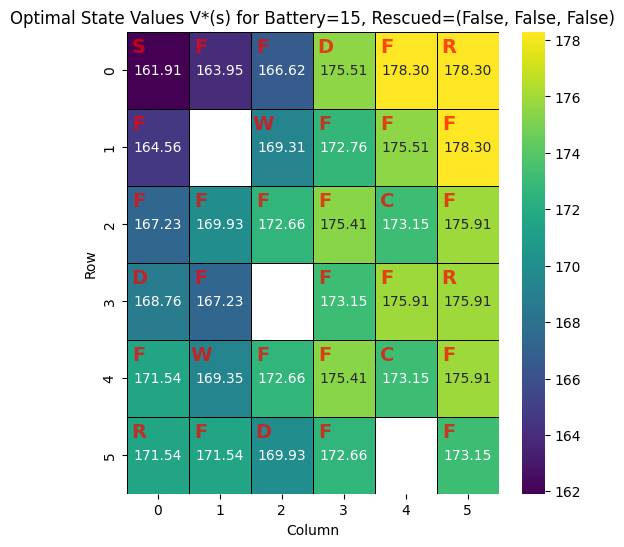


--- HEATMAP 1: Mission Start (Targeting First Rescue) ---

--- State-Value Heatmap (Fixed Battery: 15/15, Rescued Targets: [False, False, False]) ---


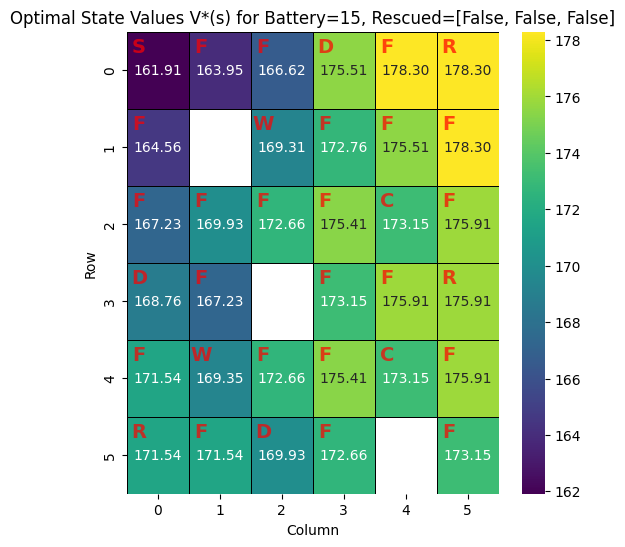


--- HEATMAP 2: After 1st Rescue (Targeting Remaining 2) ---

--- State-Value Heatmap (Fixed Battery: 10/15, Rescued Targets: [True, False, False]) ---


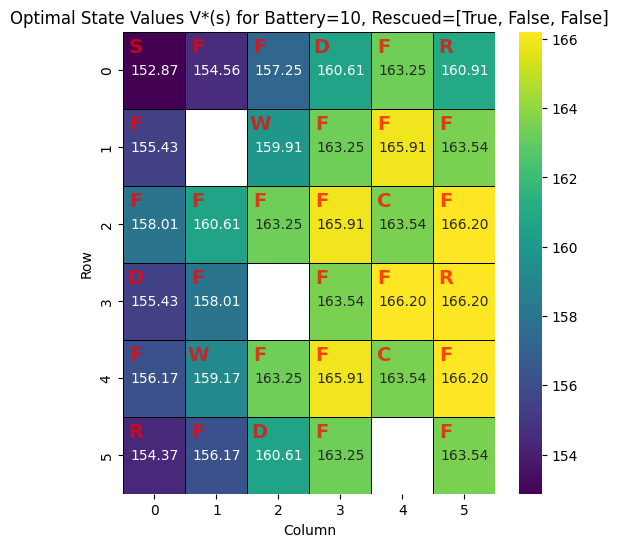


--- HEATMAP 3: Low Battery (Charging Behavior Required) ---

--- State-Value Heatmap (Fixed Battery: 3/15, Rescued Targets: [True, True, False]) ---


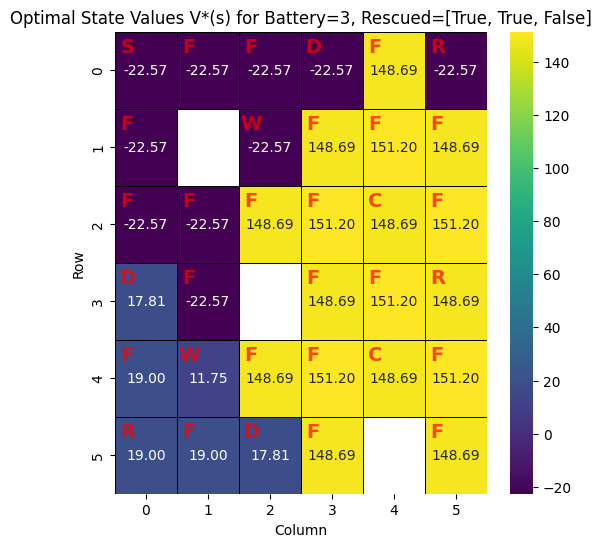


--- HEATMAP 4: Final Target Near Danger Zones ---

--- State-Value Heatmap (Fixed Battery: 15/15, Rescued Targets: [True, True, False]) ---


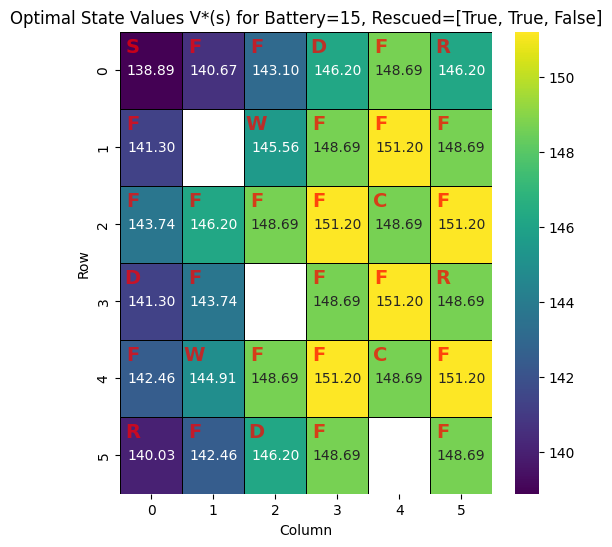

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_state_value_heatmap(env, optimal_V, state_to_idx, fixed_battery, fixed_rescued_targets):
    print(f"\n--- State-Value Heatmap (Fixed Battery: {fixed_battery}/{env.max_battery}, Rescued Targets: {fixed_rescued_targets}) ---")

    value_heatmap = np.full(env.grid_size, np.nan) # Use NaN for blocked or non-existent states

    for r in range(env.rows):
        for c in range(env.cols):
            current_pos = (r, c)
            if env.initial_grid_config[r, c] == BLOCKED:
                continue # Blocked cells have no value

            # Construct the state for this slice
            s = env._get_state_tuple(current_pos, fixed_battery, fixed_rescued_targets)

            if s in state_to_idx:
                s_idx = state_to_idx[s]
                value_heatmap[r, c] = optimal_V[s_idx]
            else:
                if env.is_terminal_state(s):
                     value_heatmap[r, c] = 0.0

    plt.figure(figsize=(env.cols, env.rows))
    
    # OPTION A: Invert the color scheme by adding '_r' to the cmap
    sns.heatmap(value_heatmap, annot=True, fmt=".2f", cmap="viridis", cbar=True, linewidths=.5, linecolor="black")
    
    plt.title(f"Optimal State Values V*(s) for Battery={fixed_battery}, Rescued={fixed_rescued_targets}")
    plt.xlabel("Column")
    plt.ylabel("Row")

    # Overlay grid cell types for context
    for r in range(env.rows):
        for c in range(env.cols):
            cell_type = env.initial_grid_config[r, c]
            if cell_type != BLOCKED:
                plt.text(c + 0.2, r + 0.2, cell_type,
                         horizontalalignment='center', verticalalignment='center',
                         color='red', fontsize=14, fontweight='bold', alpha=0.7)

    # OPTION B: Toggle Y-Axis Inversion
    # Comment this out if you want Row 0 at the top. Leave it if you want Row 0 at the bottom.
    # plt.gca().invert_yaxis() 
    
    plt.show()

# --- Run State-Value Analysis ---
if __name__ == '__main__':
    try:
        env_dp 
        optimal_V 
        state_to_idx 
    except NameError:
        print("Running DroneRescueEnv and Value Iteration setup again...")
        env_dp = DroneRescueEnv()
        optimal_V, optimal_policy, state_to_idx, idx_to_state, vi_iterations, vi_runtime, vi_final_delta = value_iteration(env_dp)

    fixed_battery_level = env_dp.max_battery 
    num_targets = len(env_dp.rescue_target_locations)
    fixed_rescued_status = tuple([False] * num_targets) 

    plot_state_value_heatmap(env_dp, optimal_V, state_to_idx, fixed_battery_level, fixed_rescued_status)

    # Stage 1: Mission Start (0/3 Rescued, Max Battery)
    print("\n--- HEATMAP 1: Mission Start (Targeting First Rescue) ---")
    plot_state_value_heatmap(env_dp, optimal_V, state_to_idx, 15, [False, False, False])

    # Stage 2: One Rescued (1/3 Rescued, Mid Battery)
    print("\n--- HEATMAP 2: After 1st Rescue (Targeting Remaining 2) ---")
    plot_state_value_heatmap(env_dp, optimal_V, state_to_idx, 10, [True, False, False])

    # Stage 3: Low Battery / Charging Priority (2/3 Rescued, Low Battery)
    print("\n--- HEATMAP 3: Low Battery (Charging Behavior Required) ---")
    plot_state_value_heatmap(env_dp, optimal_V, state_to_idx, 3, [True, True, False])

    # Stage 4: Final Target & Danger Avoidance (2/3 Rescued, Max Battery)
    print("\n--- HEATMAP 4: Final Target Near Danger Zones ---")
    plot_state_value_heatmap(env_dp, optimal_V, state_to_idx, 15, [True, True, False])

In [ ]:
# ==========================================================
# MISSION TRAJECTORY ANALYSIS USING OPTIMAL POLICY
# ==========================================================

def analyze_optimal_mission(env, optimal_policy):

    state = env.reset()

    done = False

    total_reward = 0
    steps = 0

    rescue_order = []
    charger_visits = []
    danger_visits = 0

    trajectory = []

    print("=" * 70)
    print("MISSION TRAJECTORY ANALYSIS")
    print("=" * 70)

    while not done:

        # ------------------------------------------
        # Check policy availability
        # ------------------------------------------
        if state not in optimal_policy:

            print(f"\nPolicy not found for state:")
            print(state)

            break

        action = optimal_policy[state]

        current_pos = env.current_pos

        next_state, reward, done, info = env.step(action)

        trajectory.append((current_pos, reward, env.battery))

        total_reward += reward
        steps += 1

        # ------------------------------------------
        # Rescue Tracking
        # ------------------------------------------
        if info.get("rescued", False):

            rescue_order.append(env.current_pos)

            print(
                f"[Step {steps:02d}] "
                f"RESCUE completed at {env.current_pos}"
            )

        # ------------------------------------------
        # Charger Tracking
        # ------------------------------------------
        cell_type = env.initial_grid_config[
            env.current_pos[0],
            env.current_pos[1]
        ]

        if cell_type == CHARGE:

            charger_visits.append(env.current_pos)

        # ------------------------------------------
        # Danger Tracking
        # ------------------------------------------
        if info.get("entered_danger", False):

            danger_visits += 1

        state = next_state

    # ==================================================
    # SUMMARY STATISTICS
    # ==================================================

    targets_rescued = sum(env.rescued_targets)

    rescue_efficiency = (
        targets_rescued / steps
        if steps > 0 else 0
    )

    unique_chargers = list(set(charger_visits))

    # ==================================================
    # RESULTS
    # ==================================================

    print("\n")
    print("=" * 70)
    print("MISSION RESULTS")
    print("=" * 70)

    print(
        f"Mission Status       : "
        f"{'SUCCESS' if targets_rescued == 3 else 'FAILED'}"
    )

    print(
        f"Rescues Completed    : "
        f"{targets_rescued}/3"
    )

    print(
        f"Total Steps          : "
        f"{steps}"
    )

    print(
        f"Total Reward         : "
        f"{total_reward}"
    )

    print(
        f"Final Battery        : "
        f"{env.battery}/{env.max_battery}"
    )

    print(
        f"Danger Encounters    : "
        f"{danger_visits}"
    )

    print(
        f"Rescue Efficiency    : "
        f"{rescue_efficiency:.3f} rescues/step"
    )

    print()

    print(
        f"First Rescue Visited : "
        f"{rescue_order[0] if rescue_order else 'None'}"
    )

    print(
        f"Rescue Sequence      : "
        f"{rescue_order if rescue_order else 'None'}"
    )

    print(
        f"Chargers Used        : "
        f"{unique_chargers if unique_chargers else 'None'}"
    )

    print()

    print("Trajectory:")

    for i, (pos, reward, battery) in enumerate(trajectory):

        print(
            f"Step {i:02d}: {pos} |  Reward: {reward} | Final Battery: {battery}"
        )

    return {
        "steps": steps,
        "reward": total_reward,
        "rescues_completed": targets_rescued,
        "rescue_order": rescue_order,
        "chargers_used": unique_chargers,
        "danger_encounters": danger_visits,
        "trajectory": trajectory,
        "final_battery": env.battery
    }

In [9]:
env = DroneRescueEnv()

results = analyze_optimal_mission(
    env,
    optimal_policy
)

print("\n--- POLICY INTERPRETATION ---")

print(
    f"Optimal policy rescued "
    f"{results['rescues_completed']} targets "
    f"in {results['steps']} steps."
)

print(
    f"Rescue order: "
    f"{results['rescue_order']}"
)

print(
    f"Charging stations used: "
    f"{results['chargers_used']}"
)

print(
    f"Danger zones entered: "
    f"{results['danger_encounters']}"
)

MISSION TRAJECTORY ANALYSIS
[Step 08] RESCUE completed at (3, 5)
[Step 11] RESCUE completed at (0, 5)


MISSION RESULTS
Mission Status       : FAILED
Rescues Completed    : 2/3
Total Steps          : 75
Total Reward         : 125
Final Battery        : 14/15
Danger Encounters    : 0
Rescue Efficiency    : 0.027 rescues/step

First Rescue Visited : (3, 5)
Rescue Sequence      : [(3, 5), (0, 5)]
Chargers Used        : [(2, 4)]

Trajectory:
Step 00: (0, 0) |  Reward: -1 | Final Battery: 14
Step 01: (1, 0) |  Reward: -1 | Final Battery: 14
Step 02: (2, 0) |  Reward: -1 | Final Battery: 14
Step 03: (2, 1) |  Reward: -1 | Final Battery: 14
Step 04: (2, 2) |  Reward: -1 | Final Battery: 14
Step 05: (2, 3) |  Reward: -1 | Final Battery: 14
Step 06: (2, 4) |  Reward: -1 | Final Battery: 14
Step 07: (3, 4) |  Reward: -1 | Final Battery: 14
Step 08: (3, 5) |  Reward: -1 | Final Battery: 14
Step 09: (2, 5) |  Reward: -1 | Final Battery: 14
Step 10: (1, 5) |  Reward: -1 | Final Battery: 14
Step 11:

## DP Scalability Discussion

Now, let's discuss the scalability of Dynamic Programming (DP) for this problem, especially in the context of the "Curse of Dimensionality" and how Deep Reinforcement Learning (DRL) might offer solutions for more complex scenarios, relating it to real-world autonomous drone systems.

### Curse of Dimensionality

The "Curse of Dimensionality" refers to various phenomena that arise when analyzing and organizing data in high-dimensional spaces that do not occur in low-dimensional settings. In Dynamic Programming, it specifically means that the number of states and actions grows exponentially with each additional state variable, making it computationally intractable to store and compute values for all states.

In our Drone Rescue MDP, the state is defined by:
1.  **Drone Position:** (row, col) - `Grid_Size = rows * cols` possibilities
2.  **Current Battery Level:** `MAX_BATTERY + 1` possibilities (0 to MAX_BATTERY)
3.  **Status of each Rescue Target:** `2^Num_Targets` possibilities (rescued/not rescued for each target)

Thus, the total number of states is approximately `(rows * cols) * (MAX_BATTERY + 1) * (2^Num_Targets)`.

Let's analyze how the state space changes with increased complexity:

*   **Grid becomes 10x10:**
    *   `rows * cols` changes from `5*5 = 25` to `10*10 = 100`.
    *   The state space increases by a factor of 4. This is a linear increase with respect to the number of cells, but still a significant growth in total states.

*   **More Rescue Targets are added:**
    *   If we go from 2 targets to 5 targets, `2^Num_Targets` changes from `2^2 = 4` to `2^5 = 32`.
    *   This is an exponential increase in the state space. Adding just a few more targets drastically explodes the number of states.

*   **Weather conditions become dynamic (e.g., wind strength, rain probability):**
    *   Each new weather variable (e.g., 3 levels of wind strength, 2 states for rain) would multiply the entire state space by its number of possible values (`3 * 2 = 6`).
    *   This quickly adds further exponential growth to the state space.

**Is DP sufficient?**

For small, discrete state spaces like our 5x5 grid with 2 targets and a fixed battery capacity, Dynamic Programming (Value Iteration or Policy Iteration) is efficient and guaranteed to find the optimal policy. However, as shown above, even moderately increasing the grid size, number of targets, or adding more state variables (like dynamic weather, multiple drones, payload status, or continuous state variables like precise GPS coordinates) leads to a state space that becomes too large to store in memory or compute in a reasonable time. This is where DP becomes **insufficient**.

### Why DP becomes difficult

1.  **Memory Requirements:** Storing `V(s)` and `\pi(s)` for every state `s` becomes impossible as the state space grows. Even for our 5x5 grid with 2 targets and max battery 10, the number of states is `25 * 11 * 4 = 1100`. If we had a 10x10 grid, 5 targets, and max battery 20, the states would be `100 * 21 * 32 = 67200`, which is manageable but shows the rapid growth. Add more complex factors and it quickly becomes intractable.
2.  **Computational Complexity:** Each iteration of Value Iteration requires iterating through all states and, for each state, all actions, and for each action, all possible next states. The complexity is roughly `O(S^2 * A)` or `O(S * A * S')` where S is the number of states, A is the number of actions, and S' is the average number of next states. Exponential growth in S makes this prohibitive.
3.  **Discretization Challenges:** For real-world continuous state variables (e.g., drone's exact (x,y,z) position, velocity, fuel level), DP requires discretizing the state space, which leads to a loss of information and still results in an enormous number of discrete states.

### How Deep RL methods could help

Deep Reinforcement Learning (DRL) offers powerful solutions to overcome the curse of dimensionality by using deep neural networks to approximate the value function (`V(s)`) or the policy (`\pi(s)`) directly, rather than storing them explicitly for every state. This is known as **function approximation**.

Key DRL approaches that would be beneficial:

*   **Deep Q-Networks (DQN):** For discrete action spaces (like ours), a neural network can approximate the Q-function, `Q(s, a)`, taking the state `s` as input and outputting Q-values for all actions `a`. This allows the agent to generalize across states, meaning it doesn't need to have seen every single state to make a good decision. Instead of a lookup table, it uses a network to estimate values.
*   **Policy Gradient Methods (e.g., REINFORCE, A2C, A3C):** These methods directly learn a policy that maps states to actions. A neural network can represent `\pi(s, a)`, the probability of taking action `a` in state `s`. This is particularly useful for continuous action spaces, though it can also be used for discrete actions.
*   **Actor-Critic Methods:** Combine elements of both value-based and policy-based methods, often using two neural networks: an 'actor' network for the policy and a 'critic' network for the value function, which helps guide the actor's learning.

DRL handles high-dimensional and continuous state/action spaces by:
*   **Generalization:** Neural networks can learn complex patterns and relationships from data, allowing them to generalize from observed states to unseen states.
*   **Feature Extraction:** Deep networks can automatically extract relevant features from raw sensor data (e.g., camera feeds, LiDAR data), converting high-dimensional inputs into lower-dimensional, meaningful representations.

### Relation to real-world autonomous drone systems

Real-world autonomous drone systems operate in highly complex, dynamic, and uncertain environments. Their state space is effectively continuous and astronomically large. Consider a drone:

*   **Precise Position and Orientation:** (x, y, z, roll, pitch, yaw) - continuous values.
*   **Velocity and Acceleration:** (vx, vy, vz, angular velocities) - continuous values.
*   **Battery Level:** Continuous or fine-grained discrete.
*   **Sensor Data:** High-dimensional inputs from cameras, LiDAR, GPS, IMU (e.g., recognizing obstacles, identifying civilians).
*   **Dynamic Obstacles:** Other drones, moving vehicles, people, changing weather.
*   **Multiple Objectives:** Rescuing civilians, mapping, delivering supplies, returning to base, avoiding detection.

For such systems, traditional DP is completely infeasible. DRL is the cornerstone for enabling intelligence in these drones:

*   **Navigation and Obstacle Avoidance:** DRL agents can learn to navigate complex terrains and avoid dynamic obstacles using sensor data.
*   **Target Search and Recognition:** Deep learning (a component of DRL) is used for visual recognition of rescue targets, danger zones, and charging stations from camera feeds.
*   **Adaptive Behavior:** DRL allows drones to adapt to unexpected situations and learn optimal strategies without explicit programming for every scenario.
*   **Resource Management:** Learning optimal policies for battery management, payload drop-off, and mission planning.

In summary, while DP provides a foundational understanding and optimal solutions for small MDPs, DRL is essential for scaling up to the complexity and dimensionality of real-world autonomous drone rescue operations, enabling them to make intelligent decisions in highly uncertain and dynamic environments.

### Dynamic Programming (DP) vs. Deep Reinforcement Learning (DRL) Comparison

| Feature            | Dynamic Programming (DP)                                 | Deep Reinforcement Learning (DRL)                            |
| :----------------- | :------------------------------------------------------- | :----------------------------------------------------------- |
| **State Space**    | Requires discrete, manageable state spaces.              | Can handle high-dimensional, continuous state spaces.        |
| **Action Space**   | Typically discrete.                                      | Can handle both discrete and continuous action spaces.       |
| **Optimality**     | Guaranteed to find the optimal policy for small MDPs.    | Finds a near-optimal policy; optimality not always guaranteed. |
| **Memory Usage**   | High, stores values/policies for every state (lookup table). | Lower, uses neural networks to approximate values/policies.  |
| **Computational Complexity** | High, grows exponentially with state variables.          | High for training, but efficient for inference once trained. |
| **Generalization** | Limited, struggles with unseen states.                   | Excellent, neural networks generalize to unseen states.      |
| **Model Requirement** | Requires a perfect model of the environment (transition probabilities and rewards). | Can learn without an explicit model (model-free) or with a learned model. |
| **Real-world Applicability** | Limited to simple, well-defined problems.                | Essential for complex, real-world problems (e.g., autonomous drones). |
| **Key Challenge**  | Curse of Dimensionality.                                 | Exploration vs. Exploitation, Sample Efficiency, Stability of Training. |
| **Typical Use Cases** | Planning in known, small environments.                   | Complex control tasks, game playing, robotics, autonomous systems. |
| **Approach**       | Iterative computation of value functions or policies across all states. | Uses neural networks for function approximation to learn policies or value functions from experience. |
